<a href="https://colab.research.google.com/github/Shriram0008/APS-lab-experiments/blob/main/APS_LAB_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **APS Lab-3**

### **Understanding Probability in Binary Classification**

*ML Problem:*

*Use the Breast Cancer Wisconsin dataset available directly in Scikit-learn.*

*The task is to predict whether a tumour is: Malignant or Benign*

In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
#Load the dataset
data = load_breast_cancer()

X=pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y=pd.Series(
    (data.target==0).astype(int),
    name='malignant'

# y=pd.Series(
#     data.target,
#     name='tumor_type'
# )
)

print(y.value_counts())

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Class names:",data.target_names)

malignant
0    357
1    212
Name: count, dtype: int64
Feature matrix shape: (569, 30)
Target shape: (569,)
Class names: ['malignant' 'benign']


In [3]:
#Examine the class distribution

class_counts = y.value_counts().sort_index()
class_distribution=pd.DataFrame({
    "Class": data.target_names,
    "Count": class_counts.values,
    "Probability": class_counts.values/len(y)
})

print(class_distribution)

       Class  Count  Probability
0  malignant    357     0.627417
1     benign    212     0.372583


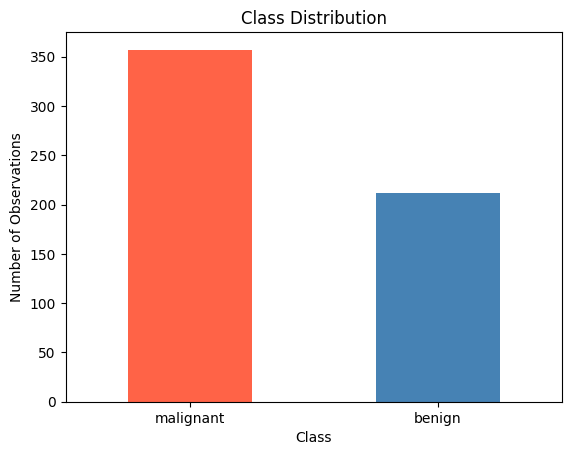

In [4]:
class_distribution.plot(
    x="Class",
    y="Count",
    kind="bar",
    legend=False,
    color=["tomato","steelblue"]
)
plt.ylabel("Number of Observations")
plt.title("Class Distribution")
plt.xticks(rotation=0)
plt.show()

In [5]:
#Create training and testing samples
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print("Training size:", len(y_train))
print("Testing size:", len(y_test))

print("\nTraining Proportion")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting Proportion")
print(y_test.value_counts(normalize=True).sort_index())

Training size: 455
Testing size: 114

Training Proportion
malignant
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing Proportion
malignant
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [6]:
# train a logistic Regression Model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=1000))])

In [7]:
#Obtain predicted Probabilites
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[9.99635432e-01 3.64568116e-04]
 [1.07465986e-08 9.99999989e-01]
 [9.57432053e-01 4.25679471e-02]
 [4.23812678e-01 5.76187322e-01]
 [4.90844511e-01 5.09155489e-01]]


In [8]:
print(probabilities[:5].sum(axis=1))

[1. 1. 1. 1. 1.]


In [9]:
results = pd.DataFrame({
    "Actual_class": y_test.values,
    "P_malignant": probabilities[:,0],
    "P_benign": probabilities[:,1]
})
print(results.head(10))

   Actual_class   P_malignant  P_benign
0             0  9.996354e-01  0.000365
1             1  1.074660e-08  1.000000
2             0  9.574321e-01  0.042568
3             1  4.238127e-01  0.576187
4             0  4.908445e-01  0.509155
5             0  9.993840e-01  0.000616
6             1  2.384659e-01  0.761534
7             0  9.989878e-01  0.001012
8             0  9.994313e-01  0.000569
9             0  9.892324e-01  0.010768


In [10]:
results["Actual_label"]=results["Actual_class"].map({
    0: "Malignant",
    1: "Benign"
})

print(
    results[
        ["Actual_label","P_malignant","P_benign"]
    ].head(10)
)

  Actual_label   P_malignant  P_benign
0    Malignant  9.996354e-01  0.000365
1       Benign  1.074660e-08  1.000000
2    Malignant  9.574321e-01  0.042568
3       Benign  4.238127e-01  0.576187
4    Malignant  4.908445e-01  0.509155
5    Malignant  9.993840e-01  0.000616
6       Benign  2.384659e-01  0.761534
7    Malignant  9.989878e-01  0.001012
8    Malignant  9.994313e-01  0.000569
9    Malignant  9.892324e-01  0.010768


In [11]:
#Use a threshold to generate predictions
threshold=0.50

results["Predicted_malignant"]=(
    results["P_malignant"]>=threshold
).astype(int)

results["Predicted_label"]=results[
    "Predicted_malignant"
    ].map({
        1: "Malignant",
        0: "Benign"
    })

print(
    results[
        [
            "Actual_label",
            "P_malignant",
            "Predicted_label"
        ]
    ].head(10)
)

  Actual_label   P_malignant Predicted_label
0    Malignant  9.996354e-01       Malignant
1       Benign  1.074660e-08          Benign
2    Malignant  9.574321e-01       Malignant
3       Benign  4.238127e-01          Benign
4    Malignant  4.908445e-01          Benign
5    Malignant  9.993840e-01       Malignant
6       Benign  2.384659e-01          Benign
7    Malignant  9.989878e-01       Malignant
8    Malignant  9.994313e-01       Malignant
9    Malignant  9.892324e-01       Malignant


In [12]:
#Compare different thresholds
for threshold in [0.30, 0.50, 0.70]:
  predictions = (
      results["P_malignant"]>= threshold
  ).astype(int)

  print(
      f"Threshold: {threshold}: ",
      f"Predicted malignant cases ={predictions.sum()}"
  )

Threshold: 0.3:  Predicted malignant cases =76
Threshold: 0.5:  Predicted malignant cases =74
Threshold: 0.7:  Predicted malignant cases =72


In [13]:
#Construct a confusion matrix
actual_malignant = (y_test.values == 0).astype(int)

for threshold in [0.30, 0.50, 0.70]:
  predicted_malignant = (
      probabilities[:,0]>= threshold
  ).astype(int)

  cm = confusion_matrix(
      actual_malignant,
      predicted_malignant
  )

  print(f"\nThreshold={threshold}")
  print(cm)


Threshold=0.3
[[38  4]
 [ 0 72]]

Threshold=0.5
[[39  3]
 [ 1 71]]

Threshold=0.7
[[41  1]
 [ 1 71]]


In [14]:
#Verify using sklearn
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Define y_pred using the previously calculated predicted malignant labels
y_pred = results["Predicted_malignant"]


print(
    "Sklearn accuracy:",
    accuracy_score(y_test,y_pred)
)
print(
    "Sklearn precision:",
    precision_score(y_test,y_pred)
)
print(
    "Sklearn recall:",
    recall_score(y_test,y_pred)
)
print(
    "Sklearn f1:",
    f1_score(y_test,y_pred)
)


Sklearn accuracy: 0.03508771929824561
Sklearn precision: 0.04054054054054054
Sklearn recall: 0.07142857142857142
Sklearn f1: 0.05172413793103448


In [29]:
#Calculate Specificity
for threshold in [0.10, 0.30, 0.50, 0.70, 0.90]:
  predicted_malignant = (
      probabilities[:,1]>= threshold
  ).astype(int)

  cm = confusion_matrix(
      y_test,
      predicted_malignant
  )
  tn = cm[0,0]
  fp = cm[0,1]
  fn = cm[1,0]
  tp = cm[1,1]

  specificity = tn/(tn+fp)
  print(f"Threshold={threshold}: Specificity={specificity}")

Threshold=0.1: Specificity=0.9305555555555556
Threshold=0.3: Specificity=0.9861111111111112
Threshold=0.5: Specificity=0.9861111111111112
Threshold=0.7: Specificity=1.0
Threshold=0.9: Specificity=1.0


In [26]:
#Compare all metrics across threshold
metric_results=[]
for threshold in [0.10, 0.30, 0.50, 0.70, 0.90]:
  predicted_malignant = (
      probabilities[:,1]>= threshold
  ).astype(int)

  cm = confusion_matrix(
      y_test,
      predicted_malignant
  )
  tn = cm[0,0]
  fp = cm[0,1]
  fn = cm[1,0]
  tp = cm[1,1]

  specificity = tn/(tn+fp)
  metric_results.append({
      "Threshold": threshold,
      "TP": tp,
      "FP": fp,
      "FN": fn,
      "TN": tn,
      "Accuracy": accuracy_score(
          y_test,
          predicted_malignant
      ),
      "Precision": precision_score(
          y_test,
          predicted_malignant,
          zero_division=0
      ),
      "Recall": recall_score(
          y_test,
          predicted_malignant,
          zero_division=0
      ),
      "Specificity": specificity,
      "F1": f1_score(
          y_test,
          predicted_malignant,
          zero_division=0
      ),
  })

display(
      pd.DataFrame(metric_results).round(3)
  )

,Threshold,TP,FP,FN,TN,Accuracy,Precision,Recall,Specificity,F1
0,0.1,41,5,1,67,0.947,0.891,0.976,0.931,0.932
1,0.3,41,1,1,71,0.982,0.976,0.976,0.986,0.976
2,0.5,39,1,3,71,0.965,0.975,0.929,0.986,0.951
3,0.7,38,0,4,72,0.965,1.000,0.905,1.000,0.950
4,0.9,33,0,9,72,0.921,1.000,0.786,1.000,0.880


In [25]:
# import numpy as np
# from sklearn.metrics import confusion_matrix

# threshold_metrics = pd.DataFrame([
#     {
#         "Threshold": threshold,
#         "TP": confusion_matrix(y_test, (model.predict_proba(X_test)[:,1]>=threshold).astype(int))[1, 1],
#         "FP": confusion_matrix(y_test, (model.predict_proba(X_test)[:,1]>=threshold).astype(int))[0, 1],
#         "FN": confusion_matrix(y_test, (model.predict_proba(X_test)[:,1]>=threshold).astype(int))[1, 0],
#         "TN": confusion_matrix(y_test, (model.predict_proba(X_test)[:,1]>=threshold).astype(int))[0, 0],
#         "Accuracy": accuracy_score(
#             y_test,
#             (model.predict_proba(X_test)[:,1]>=threshold).astype(int)
#         ),
#         "Precision": precision_score(
#             y_test,
#             (model.predict_proba(X_test)[:,1]>=threshold).astype(int),
#             zero_division=0
#         ),
#         "Recall": recall_score(
#             y_test,
#             (model.predict_proba(X_test)[:,1]>=threshold).astype(int),
#             zero_division=0
#         ),
#         "Specificity": tn / (tn + fp),

#         "F1": f1_score(
#             y_test,
#             (model.predict_proba(X_test)[:,1]>=threshold).astype(int),
#             zero_division=0
#         ),
#     }
#     for threshold in [0.10, 0.30, 0.50, 0.70, 0.90]
# ])

# display(
#     threshold_metrics.round(3)
#     )